---
title: Intoduction to the xarray EOPF backend
Subtitle: Access and explore analysis-ready and native EOPF Zarr data using xarray
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-2", "xarray-eopf", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XEOPF_INTRO)
2. [Install the xarray-eopf Backend](#Install_XEOPF_INTRO)
3. [Import modules](#Import_XEOPF_INTRO)
4. [Main Features of the xarray-eopf Backend](#Main_Features_XEOPF_INTRO)
5. [Find a Sentinel Zarr Sample via STAC](#Find_Sample_STAC_XEOPF_INTRO)
6. [Open Sentinel-2 Level-2A  in Native Mode as DataTree](#Native_DataTree_XEOPF_INTRO)
7. [Open Sentinel-2 Level-2A Reflectance Groups in Native Mode as Dataset](#Native_Subgroup_XEOPF_INTRO)
8. [Open Sentinel-2 Level-2A in Native Mode as Dataset](#Native_Dataset_XEOPF_INTRO)
9. [Open Sentinel-2 Level-2A in Analysis Mode as Dataset](#Analysis_Dataset_XEOPF_INTRO)
10. [Conclusion](#Conclusion_XEOPF_INTRO)

(Introduction_XEOPF_INTRO)=
## Introduction

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

This notebook demonstrates how to use the **xarray-eopf** backend to access EOPF Zarr datasets. It highlights the key features currently supported by the backend.

- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

:::{hint} Overview
**Questions**
- How do I install the xarray-eopf backend?
- How can I use the xarray-eopf backend effectively?
- What main features does the xarray-eopf backend provide?

**Objectives**
- Learn how to open EOPF Zarr products with ``xarray-eopf``.
- Understand the key features and capabilities of the `xarray-eopf` backend.
:::

---

(Install_XEOPF_INTRO)=
## Install the xarray-eopf Backend

The backend is implemented as an **xarray plugin** and can be installed using either `pip` or `conda/mamba` from the conda-forge channel.

- 📦 **PyPI:** [xarray-eopf on PyPI](https://pypi.org/project/xarray-eopf/)  `pip install xarray-eopf`
- 🐍 **Conda (conda-forge):** [xarray-eopf on Anaconda](https://anaconda.org/conda-forge/xarray-eopf) `conda install -c conda-forge xarray-eopf`

  You can also use **Mamba** as a faster alternative to Conda: `mamba install -c conda-forge xarray-eopf`

---

(Import_XEOPF)=
## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import datetime

import pystac_client
import xarray as xr

---

(Main_Features_XEOPF)=
## Main Features of the xarray-eopf Backend

The xarray-eopf backend for EOPF data products can be selecterd by setting `engine="eopf-zarr"` in `xarray.open_dataset(..)` and `xarray.open_datatree(..)` method. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. It supports two modes of operation:

- **Analysis Mode** *(default)*
- **Native Mode**

### Native Mode

Represents EOPF products without modification using `xarray`'s `DataTree` and `Dataset`.

- `open_dataset(path, engine="eopf-zarr", op_mode="native", chunks={})` — Returns a *flattened* version of the data tree  
- `open_datatree(path, engine="eopf-zarr", op_mode="native", chunks={})` — Returns the full `DataTree`, same as `xr.open_datatree(.., engine="zarr")`

### Analysis Mode

Provides an analysis-ready, resampled view of the data (currently for **Sentinel-2** only).

- `open_dataset(path, engine="eopf-zarr", op_mode="analysis", chunks={})` — Loads Sentinel-2 products in a harmonized, analysis-ready format  
- `open_datatree(path, engine="eopf-zarr", op_mode="analysis", chunks={})` — Not implemented in this mode (`NotImplementedError`)
  

In the following sections, we demonstrate these functions using a Sentinel-2 L2A product.

For additional examples, refer to the notebooks provided for each Sentinel-1, Sentinel-2, and Sentinel-3 product, available in both *native* and *analysis* modes.

The *native mode* operates identically across all Sentinel missions. In contrast, the *analysis mode* is customized for each individual mission, as illustrated in the respective notebook examples.

Further information about the analysis mode for each Sentinel mission can be found in the [xarray-eopf Guide](https://eopf-sample-service.github.io/xarray-eopf/guide/).

---

(Find_Sample_STAC)=
## Find a Sentinel Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-2-l2a) to search for a Sentinel-2 tile. Here, the `query` parameter is used to select tiles with less than 40% cloud cover, improving the chances of a clear plot.

In [2]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[7.2, 44.5, 7.4, 44.7],
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
        query={"eo:cloud_cover": {"lt": 40}},
    ).items()
)
items

[<Item id=S2A_MSIL2A_20260326T102701_N0512_R108_T32TLQ_20260326T172711>,
 <Item id=S2B_MSIL2A_20260326T102019_N0512_R065_T32TLQ_20260326T155529>,
 <Item id=S2B_MSIL2A_20260319T103019_N0512_R108_T32TLQ_20260319T151320>,
 <Item id=S2A_MSIL2A_20260316T103041_N0512_R108_T32TLQ_20260316T184508>,
 <Item id=S2B_MSIL2A_20260316T101649_N0512_R065_T32TLQ_20260316T155405>,
 <Item id=S2A_MSIL2A_20260313T101741_N0512_R065_T32TLQ_20260313T171916>,
 <Item id=S2C_MSIL2A_20260304T102921_N0512_R108_T32TLQ_20260304T160811>]

Next, we can inspect the item’s contents, including the additional field `xarray:open_datatree_kwargs`, which provides the arguments needed to open the product using Xarray’s `eopf-zarr` engine.

In [3]:
item = items[0]
item

<Item id=S2A_MSIL2A_20260326T102701_N0512_R108_T32TLQ_20260326T172711>

(Native_DataTree_XEOPF_INTRO)=
## Open Sentinel-2 Level-2A  in Native Mode as DataTree

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [4]:
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]
)
dt

<xarray.DataTree>
Group: /
│   Attributes: (3)
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 7)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * y                              (y) float32 92B 5e+06 4.995e+06 ... 4.89e+06
│   │         * x                              (x) float32 92B 3e+05 3.05e+05 ... 4.1e+05
│   │         * detector                       (detector) object 56B 'd06' 'd07' ... 'd12'
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 770kB dask.array<chunksize=(13, 7, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) float32 44kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │   │         * x        (x) float32 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) float32 22kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │   │         * x        (x) float32 22kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * y        (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
│   │   │             * x        (x) float32 7kB 3e+05 3.001e+05 3.002e+05 ... 4.097e+05 4.098e+05
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   ├── Group: /conditions/mask/l1c_classification
│   │   │   └── Group: /conditions/mask/l1c_classification/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │

As an example, we plot the red band (`b04`) at 60 meters resolution, which will trigger loading and visualization of the data. 

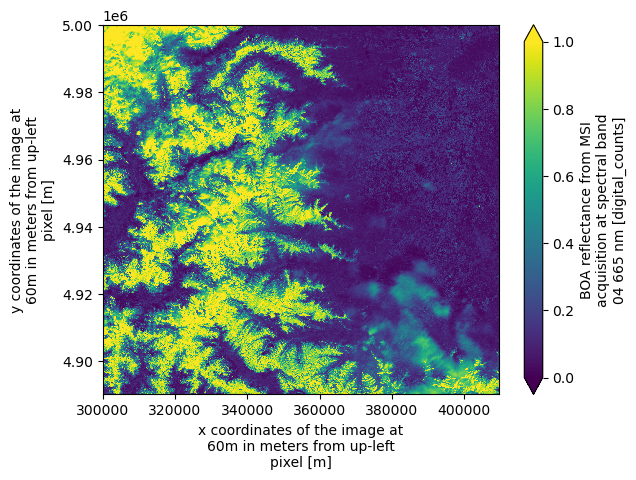

In [5]:
dt.measurements.reflectance.r60m.b04.plot.imshow(vmin=0, vmax=1)

(Native_Subgroup_XEOPF_INTRO)=
## Open Sentinel-2 Level-2A Reflectance Groups in Native Mode as Dataset

Similarly, we can open the individual reflectance groups at **10 m** (asset `"SR_10m"`), **20 m** (asset `"SR_20m"`), and **60 m** (asset `"SR_60m"`) to access each group as an `xarray.Dataset`, as shown below:

In [6]:
ds = xr.open_dataset(
    item.assets["SR_60m"].href,
    **item.assets["SR_60m"].extra_fields["xarray:open_dataset_kwargs"]
)
ds

<xarray.Dataset> Size: 295MB
Dimensions:  (y: 1830, x: 1830)
Coordinates:
  * y        (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06 4.89e+06
  * x        (x) float32 7kB 3e+05 3.001e+05 3.002e+05 ... 4.097e+05 4.098e+05
Data variables:
    b01      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b02      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b06      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b07      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b11      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a      (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>

We can plot an RGB image as an example, using the red (`b04`), green (`b03`), and blue (`b02`) spectral bands.

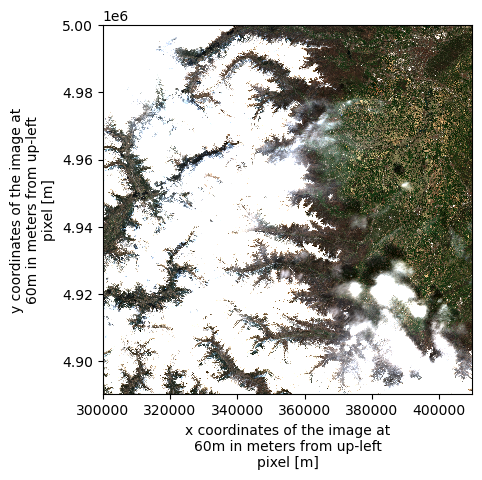

In [7]:
ax = (
    (ds[["b04", "b03", "b02"]].to_dataarray(dim="band") / 0.3)
    .clip(0, 1)
    .plot.imshow(rgb="band")
)
ax.axes.set_aspect("equal")

(Native_Dataset_XEOPF_INTRO)=
## Open Sentinel-2 Level-2A in Native Mode as Dataset

The `xarray.DataTree` data model is relatively new, introduced in [xarray v2024.10.0](https://docs.xarray.dev/en/v2024.10.0/whats-new.html) (October 2024). To support compatibility with existing workflows that rely on the traditional `xr.Dataset` model, we provide the function `xarray.open_dataset(path, engine="eopf-zarr", op_mode="native", **kwargs)`. This function flattens the `DataTree` structure and returns a single `xr.Dataset`.

In this process, hierarchical groups within the Zarr product are removed by converting their contents into standalone datasets and merging them into one. To ensure uniqueness, variable and dimension names are prefixed with their original group paths, using an underscore (`_`) as the default separator. For example, a variable named `b02` located in the group `measurements/reflectance/r10m` will be renamed to `measurements_reflectance_r10m_b02` in the returned dataset.


In [8]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
)
ds

<xarray.Dataset> Size: 11GB
Dimensions:                                            (
                                                        conditions_geometry_angle: 2,
                                                        conditions_geometry_band: 13,
                                                        conditions_geometry_y: 23,
                                                        conditions_geometry_x: 23,
                                                        conditions_geometry_detector: 7,
                                                        ...
                                                        quality_mask_r20m_y: 5490,
                                                        quality_mask_r20m_x: 5490,
                                                        quality_mask_r60m_y: 1830,
                                                        quality_mask_r60m_x: 1830,
                                                        quality_probability_y: 5490,
                                                        quality_probability_x: 5490)
Coordinates: (12/41)
  * conditions_geometry_angle                          (conditions_geometry_angle) <U7 56B ...
  * conditions_geometry_band                           (conditions_geometry_band) <U3 156B ...
  * conditions_geometry_y                              (conditions_geometry_y) float32 92B ...
  * conditions_geometry_x                              (conditions_geometry_x) float32 92B ...
  * conditions_geometry_detector                       (conditions_geometry_detector) object 56B ...
  * conditions_mask_detector_footprint_r10m_y          (conditions_mask_detector_footprint_r10m_y) float32 44kB ...
    ...                                                 ...
  * quality_mask_r20m_y                                (quality_mask_r20m_y) float32 22kB ...
  * quality_mask_r20m_x                                (quality_mask_r20m_x) float32 22kB ...
  * quality_mask_r60m_y                                (quality_mask_r60m_y) float32 7kB ...
  * quality_mask_r60m_x                                (quality_mask_r60m_x) float32 7kB ...
  * quality_probability_y                              (quality_probability_y) float32 22kB ...
  * quality_probability_x                              (quality_probability_x) float32 22kB ...
Data variables: (12/83)
    conditions_geometry_mean_sun_angles                (conditions_geometry_angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    conditions_geometry_mean_viewing_incidence_angles  (conditions_geometry_band, conditions_geometry_angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
    conditions_geometry_sun_angles                     (conditions_geometry_angle, conditions_geometry_y, conditions_geometry_x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
    conditions_geometry_viewing_incidence_angles       (conditions_geometry_band, conditions_geometry_detector, conditions_geometry_angle, conditions_geometry_y, conditions_geometry_x) float64 770kB dask.array<chunksize=(13, 7, 2, 23, 23), meta=np.ndarray>
    conditions_mask_detector_footprint_r10m_b02        (conditions_mask_detector_footprint_r10m_y, conditions_mask_detector_footprint_r10m_x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
    conditions_mask_detector_footprint_r10m_b03        (conditions_mask_detector_footprint_r10m_y, conditions_mask_detector_footprint_r10m_x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
    ...                                                 ...
    quality_mask_r20m_b8a                              (quality_mask_r20m_y, quality_mask_r20m_x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    quality_mask_r60m_b01                              (quality_mask_r60m_y, quality_mask_r60m_x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    quality_mask_r60m_b09                              (quality_mask_r60m_y, quality_mask_r60m_x) uint8 

The separator character used in flattened variable names can be customized via the `group_sep` parameter. Additionally, you can filter the returned variables using the `variables` keyword argument, which accepts a string, an iterable of names, or a regular expression (regex) pattern.

In [9]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
    group_sep="/",
    variables="measurements/r60m/b0[234]",
)
ds

<xarray.Dataset> Size: 80MB
Dimensions:                (measurements/r60m/y: 1830, measurements/r60m/x: 1830)
Coordinates:
  * measurements/r60m/y    (measurements/r60m/y) float32 7kB 5e+06 ... 4.89e+06
  * measurements/r60m/x    (measurements/r60m/x) float32 7kB 3e+05 ... 4.098e+05
Data variables:
    measurements/r60m/b02  (measurements/r60m/y, measurements/r60m/x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    measurements/r60m/b03  (measurements/r60m/y, measurements/r60m/x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    measurements/r60m/b04  (measurements/r60m/y, measurements/r60m/x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (3)

Following the previous steps, we can now select a data variable and display the RGB image as an example.


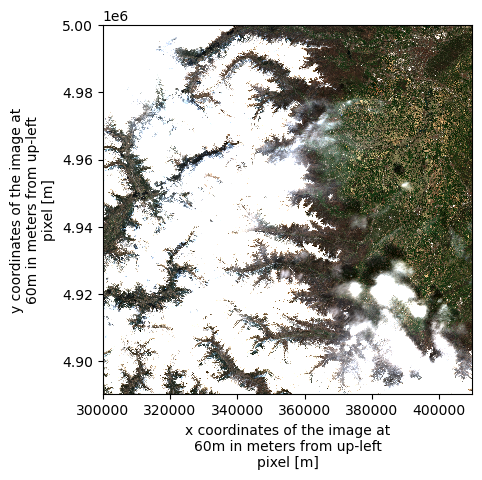

In [10]:
array = ds[
    ["measurements/r60m/b04", "measurements/r60m/b03", "measurements/r60m/b02"]
].to_dataarray(dim="band")
ax = (array / 0.3).clip(0, 1).plot.imshow(rgb="band")
ax.axes.set_aspect("equal")

(Analysis_Dataset_XEOPF_INTRO)=
## Open Sentinel-2 Level-2A in Analysis Mode as Dataset

Next, we use the `"product"` asset to open the Sentinel-2 product in **analysis mode**, which presents EOPF products as an **analysis-ready xarray `Dataset`** with a **single, unified grid mapping**. For Sentinel-2, all variables are automatically **upscaled or downscaled** so that the dataset shares one consistent pair of `x` and `y` coordinates. Note that **analysis mode** is the default in the xarray EOPF plugin.

We use **60 m resolution** to keep plotting fast, as full-resolution data can be slow to render in Matplotlib. For full details on `xarray.open_dataset` configuration options, see the [xarray-eopf documentation](https://eopf-sample-service.github.io/xarray-eopf/api/#xarray_eopf.backend.EopfBackend.open_dataset).

In [11]:
ds = xr.open_dataset(
    items[0].assets["product"].href, engine="eopf-zarr", resolution=60, chunks={}
)
ds

<xarray.Dataset> Size: 352MB
Dimensions:      (y: 1830, x: 1830)
Coordinates:
  * y            (y) float32 7kB 5e+06 5e+06 5e+06 ... 4.89e+06 4.89e+06
  * x            (x) float32 7kB 3e+05 3.001e+05 ... 4.097e+05 4.098e+05
    spatial_ref  int64 8B ...
Data variables: (12/15)
    b08          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    cld          (y, x) float32 13MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    snw          (y, x) float32 13MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b02          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b07          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b11          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b12          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 27MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    scl          (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (25)

And we can plot one spectral band as example: 

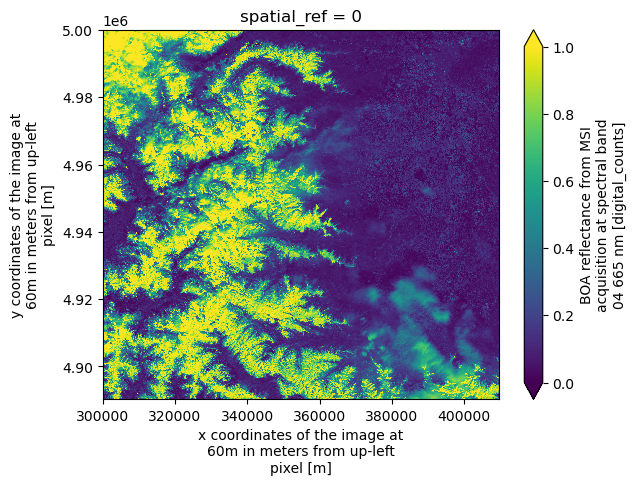

In [12]:
ds.b04.plot(vmin=0, vmax=1)

(Conclusion_XEOPF_INTRO)=
## Conclusion

This notebook highlighted the main features of the **xarray-eopf** backend, which enables seamless access to EOPF Zarr products using familiar Xarray methods (`xr.open_dataset` and `xr.open_datatree`) by specifying `engine="eopf-zarr"`. Key takeaways:

- **Two operation modes:**
  - `op_mode="native"`: Represents EOPF products without modification using Xarray's `DataTree` and `Dataset` structures.
  - `op_mode="analysis"`: Provides an analysis-ready, resampled view of the data and is available for `xarray.open_dataset` only.
- Opening parameters are integrated into the STAC items, allowing streamlined data access and management.
- Subgroups of the data tree are resolved via individual STAC assets and can be accessed with `xarray.open_dataset` using the provided parameters.

**Future Examples**

For additional examples, see the notebooks for **Sentinel-1, Sentinel-2, and Sentinel-3** products, in both native and analysis modes.

---

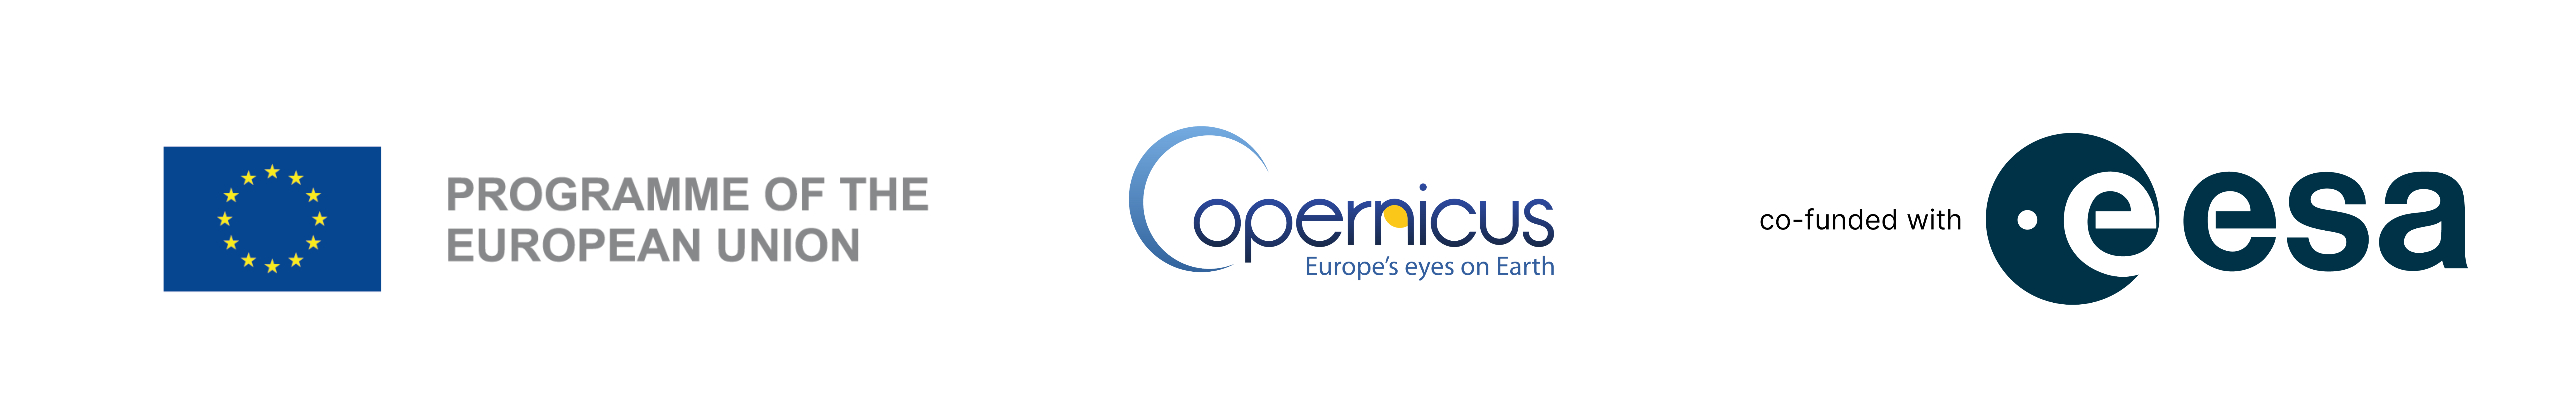